In [ ]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path('../python_code').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from DataGenerator import HyperspectralTorchDataset
from ManualCNNClassifier import HyperspectralMultiCNN

In [34]:
healthy_image_path = Path("resources/Tray_2_row_10_column_8.npy")
infected_image_path = Path("resources/Tray_2_row_20_column_0.npy")
model_path = Path("resources/HyperspectralCNN_64-127-568-bands-0.971-accuracy.pt")

model_name = model_path.stem
bands_str = model_name.split("_")[1].split("-bands")[0]
bands = list(map(int, bands_str.split("-")))
print("Bands:", bands)

Bands: [64, 127, 568]


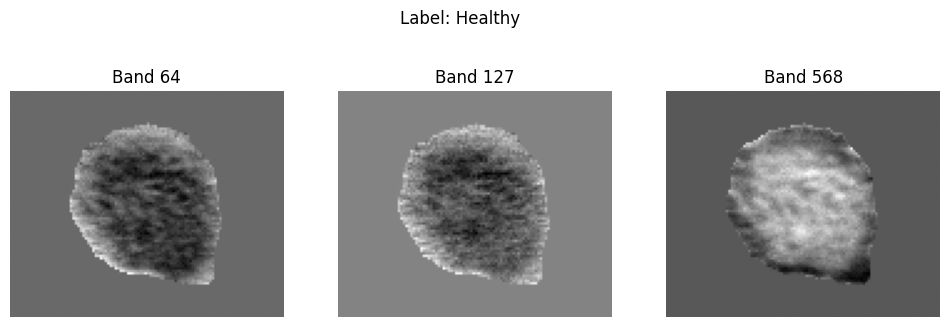

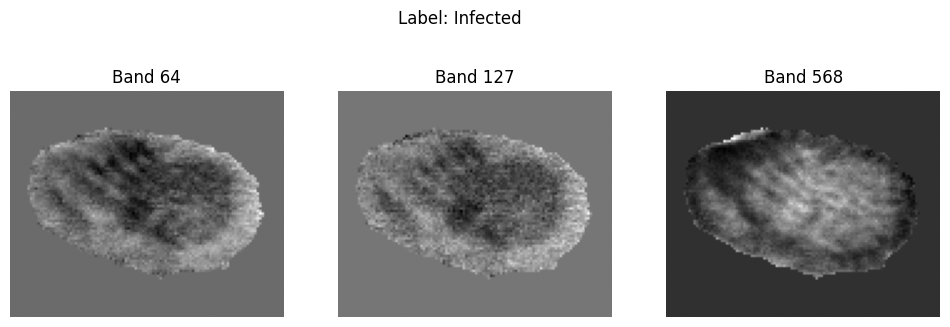

In [29]:


labels_map = {0: 'Healthy', 1: 'Infected'}
image_paths = [(healthy_image_path, 0), (infected_image_path, 1)]

for path, label in image_paths:
    image = np.load(path)
    plt.figure(figsize=(12, 4))
    for i, b in enumerate(bands):
        plt.subplot(1, len(bands), i+1)
        plt.imshow(image[:, :, b], cmap='gray')
        plt.title(f"Band {b}")
        plt.axis('off')
    plt.suptitle(f"Label: {labels_map[label]}")
    plt.show()

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Prepare Image ---
healthy_image = np.load(healthy_image_path)
height, width = healthy_image.shape[:2]
shape = (height, width, len(bands))

dataset = HyperspectralTorchDataset([str(healthy_image_path), str(infected_image_path)], [0, 1], bands, shape)
dataset = HyperspectralTorchDataset([str(healthy_image_path)], [0], bands, shape)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

for image, _ in loader:
    image = image.to(device)

In [ ]:
model = HyperspectralMultiCNN(len(bands))
state = torch.load(model_path, map_location=device)
state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
model_state = model.state_dict()
for key in model_state.keys():
    if key in state and state[key].shape == model_state[key].shape:
        model_state[key] = state[key]
model.load_state_dict(model_state)
model.to(device).eval()

In [32]:
preds, targets = [], []
for x, y in loader:
    with torch.no_grad():
        logits = model(x)
        if isinstance(logits, tuple):
            logits = logits[0]
        preds.extend((logits > 0.5).int().cpu().numpy().flatten())
        targets.extend(y.cpu().numpy())
accuracy = (np.array(preds) == np.array(targets)).mean()
        
print(accuracy)

1.0
